<a href="https://colab.research.google.com/github/akriti404/Deep-Learning-Lab/blob/main/lab3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/tmp/ipykernel_797/1475022467.py:67: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([''] + batch_sizes); ax.set_yticklabels([''] + learning_rates)
/tmp/ipykernel_797/1475022467.py:67: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([''] + batch_sizes); ax.set_yticklabels([''] + learning_rates)


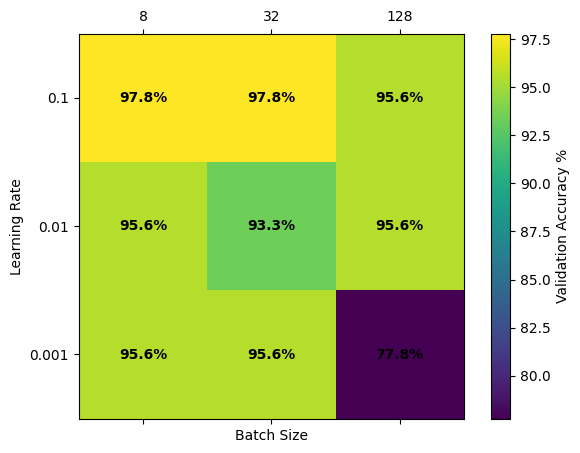

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt

# 1. Build Split Pipeline
wine = load_wine()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(wine.data)
X_train, X_val, y_train, y_val = train_test_split(X_scaled, wine.target, test_size=0.25, random_state=7)

train_ds = TensorDataset(torch.tensor(X_train, dtype=torch.float32), torch.tensor(y_train, dtype=torch.long))
X_val_t = torch.tensor(X_val, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.long)

# 2. Clean Architecture Definition
class WineTuningNet(nn.Module):
    def __init__(self):
        super(WineTuningNet, self).__init__()
        self.net = nn.Sequential(nn.Linear(13, 16), nn.ReLU(), nn.Linear(16, 3))
    def forward(self, x): return self.net(x)

# 3. Parameters Space Matrix
learning_rates = [0.1, 0.01, 0.001]
batch_sizes = [8, 32, 128]
epochs = 30
criterion = nn.CrossEntropyLoss()
grid_results = {}

# 4. Search Execution Execution
for lr in learning_rates:
    for bs in batch_sizes:
        train_loader = DataLoader(train_ds, batch_size=bs, shuffle=True)
        torch.manual_seed(7)
        model = WineTuningNet()
        optimizer = optim.Adam(model.parameters(), lr=lr)

        # Train Execution
        model.train()
        for epoch in range(epochs):
            for bx, by in train_loader:
                optimizer.zero_grad()
                criterion(model(bx), by).backward()
                optimizer.step()

        # Val Score Evaluation
        model.eval()
        with torch.no_grad():
            preds = model(X_val_t).argmax(dim=1)
            acc = (preds == y_val_t).float().mean().item() * 100
        grid_results[(lr, bs)] = acc

# 5. Formulate Matrix & Plot Map Diagram
matrix = np.zeros((len(learning_rates), len(batch_sizes)))
for i, lr in enumerate(learning_rates):
    for j, bs in enumerate(batch_sizes):
        matrix[i, j] = grid_results[(lr, bs)]

fig, ax = plt.subplots(figsize=(7, 5))
cax = ax.matshow(matrix, cmap='viridis')
fig.colorbar(cax, label='Validation Accuracy %')
ax.set_xticklabels([''] + batch_sizes); ax.set_yticklabels([''] + learning_rates)
plt.xlabel('Batch Size'); plt.ylabel('Learning Rate')

for i in range(len(learning_rates)):
    for j in range(len(batch_sizes)):
        ax.text(j, i, f'{matrix[i, j]:.1f}%', va='center', ha='center', color='white' if matrix[i,j] < 75 else 'black', fontweight='bold')
plt.show()